In [9]:
import torch
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM

In [ ]:
# Get a model and an image
weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()

preprocess = weights.transforms()
img = decode_image("/Users/wilgotlucaci/Desktop/white-lab.webp")

input_tensor = preprocess(img)

with LayerCAM(model) as cam_extractor:
  out = model(input_tensor.unsqueeze(0))
  # Retrieve the CAM by passing the class index and the model output
target_class = 208 
activation_map = cam_extractor(target_class, out)

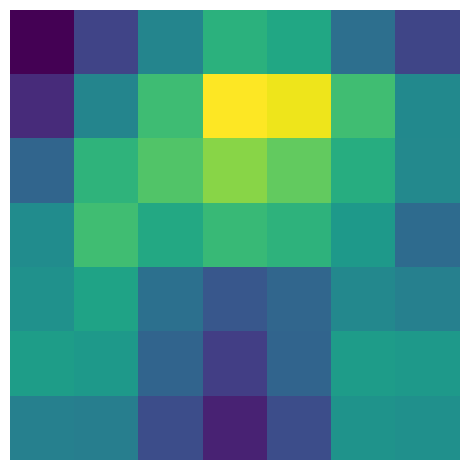

In [11]:
import matplotlib.pyplot as plt
# Visualize the raw CAM
plt.imshow(activation_map[0].squeeze(0).numpy()); plt.axis('off'); plt.tight_layout(); plt.show()

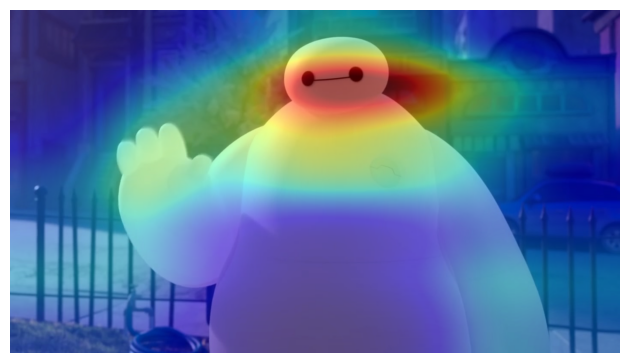

In [12]:
import matplotlib.pyplot as plt
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask

# Resize the CAM and overlay it
result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)
plt.imshow(result); plt.axis('off'); plt.tight_layout(); plt.show()

In [13]:
model.eval()
preprocess = weights.transforms()
batch = preprocess(img).unsqueeze(0)
prediction = model(batch).squeeze(0).softmax(0)

In [14]:
prediction.detach()

tensor([1.1223e-05, 6.2365e-04, 8.6774e-05, 6.0535e-05, 5.1021e-04, 1.1308e-03,
        5.7398e-04, 5.4109e-06, 1.1310e-05, 3.8131e-06, 1.9306e-05, 4.3251e-05,
        2.3041e-05, 9.5145e-05, 2.0182e-04, 3.5066e-05, 2.2925e-05, 4.6069e-05,
        1.8397e-04, 9.9759e-05, 3.2153e-05, 2.0981e-04, 8.6455e-05, 6.0640e-05,
        3.3817e-04, 6.4673e-06, 8.8226e-06, 2.5220e-05, 1.1195e-05, 7.7698e-04,
        6.2969e-05, 1.1615e-04, 8.4061e-05, 2.7889e-04, 1.8113e-04, 5.1085e-05,
        6.6079e-04, 5.6471e-05, 1.4543e-05, 5.5357e-06, 1.1576e-05, 1.7070e-05,
        1.3058e-05, 7.4922e-05, 1.3441e-05, 6.1288e-06, 3.4030e-05, 1.5870e-04,
        1.2782e-05, 9.7189e-06, 1.4892e-05, 2.0666e-04, 5.2559e-05, 2.3095e-05,
        9.4660e-06, 2.8492e-05, 8.2867e-06, 8.8587e-06, 1.0847e-05, 8.8566e-06,
        3.6455e-05, 1.1522e-05, 8.1737e-06, 9.6471e-06, 6.8332e-05, 1.9581e-05,
        6.0230e-06, 1.7765e-05, 1.5985e-05, 1.2909e-04, 1.8383e-05, 8.8988e-06,
        1.8328e-05, 3.4713e-05, 2.7860e-

In [15]:
import json
import torch


def predict_class(output_tensor: torch.Tensor, class_index_path: str) -> dict:
    """
    Maps the maximum logit in a softmax output tensor to an ImageNet class name.

    Args:
        output_tensor:    1D or 2D tensor of shape (1000,) or (1, 1000),
                          typically the output of a softmax layer from ResNet18.
        class_index_path: Path to the imagenet_class_index.json file.

    Returns:
        A dict with keys:
            - 'class_index'  (int)   : index of the predicted class (0–999)
            - 'class_id'     (str)   : WordNet synset ID, e.g. "n01440764"
            - 'class_name'   (str)   : human-readable label, e.g. "tench"
            - 'confidence'   (float) : softmax probability of the top class
    """
    with open(class_index_path, "r") as f:
        class_index = json.load(f)  # keys are str "0".."999"

    # Flatten to 1-D in case the tensor has a batch dimension
    probs = output_tensor.squeeze()          # (1000,)
    if probs.ndim != 1 or probs.shape[0] != 1000:
        raise ValueError(
            f"Expected a tensor of 1000 values, got shape {tuple(output_tensor.shape)}"
        )

    top_idx = int(probs.argmax())            # index of highest probability
    synset_id, class_name = class_index[str(top_idx)]

    return {
        "class_index": top_idx,
        "class_id":    synset_id,
        "class_name":  class_name,
        "confidence":  float(probs[top_idx]),
    }

In [16]:
predict_class(prediction.detach(), "/Users/wilgotlucaci/Downloads/imagenet_class_index.json")

{'class_index': 719,
 'class_id': 'n03935335',
 'class_name': 'piggy_bank',
 'confidence': 0.0810084268450737}

In [ ]:
def run_cam(img_path, target_class, title):

    img = decode_image(img_path)

    input_tensor = preprocess(img)

    with LayerCAM(model) as cam_extractor:

        out = model(input_tensor.unsqueeze(0))

        activation_map = cam_extractor(target_class, out)

    result = overlay_mask(

        to_pil_image(img),

        to_pil_image(activation_map[0].squeeze(0), mode='F'),

        alpha=0.5

    )

    plt.imshow(result)

    plt.title(title)

    plt.axis("off")

    plt.tight_layout()

    plt.show()

    return out